In [1]:
import torch
from torch import nn
from torch import optim
from torchvision import datasets
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import ParameterGrid
from sklearn.model_selection import StratifiedKFold,KFold
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from CrossValidation import CrossValidation
from sklearn.datasets import load_iris
from torch.utils.data import TensorDataset, DataLoader
from sklearn import preprocessing
import AutoUtils

MNIST_FOLDER = "data"
inputData = "MNIST"

Matplotlib created a temporary cache directory at /tmp/matplotlib-9fwl2t1a because the default path (/home/.config/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:
DEVICE = None
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)} is available.")
    DEVICE = "cuda:0"
else:
    print("No GPU available. Training will run on CPU.")
    DEVICE = "cpu"

No GPU available. Training will run on CPU.


In [3]:
# Transforms images to a PyTorch Tensor
tensor_transform = transforms.ToTensor()
 
if inputData == "MNIST":
    dataset = datasets.MNIST(root = MNIST_FOLDER,
                            train = True,
                            download = True,
                            transform = tensor_transform)
    

    test_dataset = datasets.MNIST(root = MNIST_FOLDER,
                            train = False,
                            download = True,
                            transform = tensor_transform)
else:
    iris = load_iris()
    dataset, test_dataset, dataset_target, test_target = train_test_split(
        iris.data, iris.target, test_size=0.2, random_state=42)
    scaler = preprocessing.StandardScaler().fit(dataset)
    dataset = scaler.transform(dataset) 
    test_dataset = scaler.transform(test_dataset) 
    dataset = TensorDataset(torch.tensor(dataset).float(), torch.tensor(dataset_target).float())
    # test_dataset = TensorDataset(torch.tensor(test_dataset).float(), torch.tensor(test_target).float())

# Autoencoders

## Simple Autoencoder

In [4]:
def SimpleTrain(model, 
        optimizer,
        loss_function,
        train_loader,
        input_shape):
        acumulated_loss = 0
        model.train()
        num_batches = len(train_loader) 
        for (image, _) in train_loader:
                input_data = torch.flatten(image, start_dim=1).to(DEVICE) 
                # Consume input
                model_output = model(input_data)
                loss = loss_function(model_output, input_data)
                # Update weights
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                acumulated_loss += loss.item()
        avg_loss = acumulated_loss / num_batches
        return avg_loss, model

In [5]:
def SimpleValidation(model, 
        optimizer,
        loss_function,
        validation_loader,
        input_shape):
        model.eval()
        valid_loss = 0
        num_batches = len(validation_loader)
        with torch.no_grad():  # Disable gradient computation
                for (image, _)  in validation_loader:
                        input_data = torch.flatten(image, start_dim=1).to(DEVICE) 
                        model_output = model(input_data)
                        loss = loss_function(model_output, input_data)
                        valid_loss += loss.item()
                avg_valid_loss = valid_loss / num_batches 
        return avg_valid_loss

In [6]:
import SimpleAutoencoder as sae

if (inputData == "MNIST"):
    input_shape = 28 * 28
else:
    input_shape = 4

param_grid = ParameterGrid(
    {
        'epoch': [10],
        'lr': [1e-3]
    })

results = {
    "train_loss": list(),
    "validation_loss": list(),
    "epoch": list(),
    "fold": list()}
best_model_flag = 9e99
best_model = None

for model_configuration in param_grid:
    epoch = model_configuration["epoch"]
    lr = model_configuration["lr"]
    print(f"{epoch = }\t{lr = }")
    cv = CrossValidation(3)
    for fold_index, dataloaders in enumerate(cv.GetSplitDataloader(dataset)):
        train_loader, validation_loader = dataloaders
        # Model
        model = sae.SimpleAutoencoder(input_shape).to(DEVICE)
        loss_function = nn.MSELoss()
        optimizer = optim.Adam(model.parameters(),
                                lr = lr)
        print(f"{fold_index = }")
        for n_epoch in tqdm(range(epoch)):
            train_loss, model = SimpleTrain(model, optimizer, loss_function, train_loader,
                            input_shape)
            validation_loss = SimpleValidation(model, optimizer, loss_function, validation_loader,
                            input_shape)
            results["train_loss"].append(train_loss)
            results["validation_loss"].append(validation_loss)
            results["fold"].append(fold_index)
            if train_loss <= best_model_flag:
                best_model = model
                best_model_flag = train_loss

print(best_model)

epoch = 10	lr = 0.001
fold_index = 0


100%|██████████| 10/10 [01:09<00:00,  6.97s/it]


fold_index = 1


100%|██████████| 10/10 [01:09<00:00,  6.98s/it]


fold_index = 2


100%|██████████| 10/10 [01:09<00:00,  6.93s/it]

SimpleAutoencoder(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): Tanh()
    (2): Linear(in_features=256, out_features=64, bias=True)
    (3): Tanh()
  )
  (decoder): Sequential(
    (0): Linear(in_features=64, out_features=256, bias=True)
    (1): Tanh()
    (2): Linear(in_features=256, out_features=784, bias=True)
    (3): Tanh()
    (4): Linear(in_features=784, out_features=784, bias=True)
    (5): Sigmoid()
  )
)


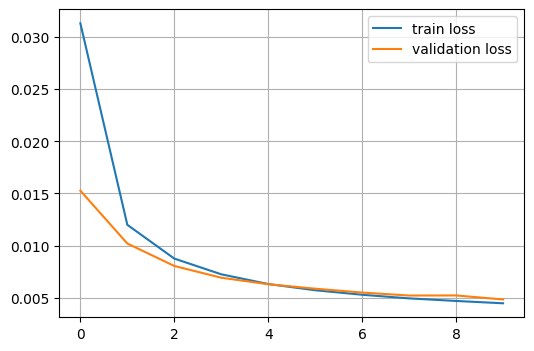

In [7]:
AutoUtils.PlotKKFoldLoss(results)

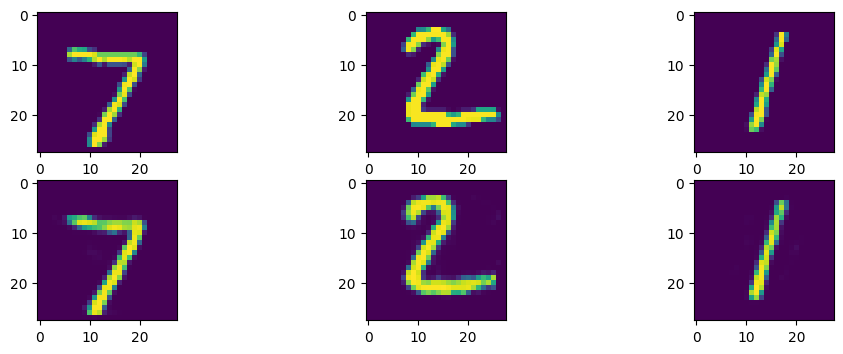

In [8]:
numbers_to_plot = 3
fig, ax = plt.subplots(2,3, figsize=(12,4))

for index, (image, _) in enumerate(test_dataset): 
    if (index >= numbers_to_plot):
        break
    item = image.reshape(-1, 28, 28)
    ax[0,index].imshow(item[0].detach().numpy())
    model.eval()
    item = best_model(image.reshape(-1, input_shape).to(DEVICE))
    item = item.reshape(-1, 28, 28).cpu()
    ax[1,index].imshow(item[0].detach().numpy())

plt.show()

## Sparce Autoencoder

In [10]:
def SparceTrain(model, 
        optimizer,
        loss_function,
        train_loader,
        input_shape,
        regularizer,
        hyper_parameter):
        acumulated_loss = 0
        model.train()
        num_batches = len(train_loader) 
        for (image, _) in train_loader:
                optimizer.zero_grad()
                input_data = torch.flatten(image, start_dim=1).to(DEVICE) 
                # Consume input
                model_output = model(input_data)
                loss = loss_function(model_output, input_data)
                # regularizer_value = model.sparsity_penalty(encoded, hyper_parameter)
                # loss += regularizer_value
                # Update weights
                loss.backward()
                optimizer.step()
                acumulated_loss += loss.item()
        avg_loss = acumulated_loss / num_batches
        return avg_loss, model

In [9]:
def SparceValidation(model, 
        optimizer,
        loss_function,
        validation_loader,
        input_shape,
        regularizer,
        hyper_parameter):
        model.eval()
        valid_loss = 0
        num_batches = len(validation_loader)
        with torch.no_grad():  # Disable gradient computation
                for (image, _)  in validation_loader:
                        input_data = torch.flatten(image, start_dim=1).to(DEVICE) 
                        # Consume input
                        model_output = model(input_data)
                        loss = loss_function(model_output, input_data)
                        # regularizer_value = model.sparsity_penalty(encoded, hyper_parameter)
                        # loss += regularizer_value
                        valid_loss += loss.item()
                avg_valid_loss = valid_loss / num_batches 
        return avg_valid_loss

### Regularization L1

In [6]:
def L1Regularizer(model, model_output, input_data, hyper_parameter):
    l1_norm = sum(torch.linalg.norm(p, 1) for p in model.parameters())
    return hyper_parameter * l1_norm

In [11]:
import SimpleAutoencoder as sae

if (inputData == "MNIST"):
    input_shape = 28 * 28
else:
    input_shape = 4

param_grid = ParameterGrid(
    {
        'epoch': [10],
        'lr': [1e-3],
        "hyper_parameter": [0.001]
    })

results = {
    "train_loss": list(),
    "validation_loss": list(),
    "epoch": list(),
    "fold": list()}
best_model_flag = 9e99
best_model = None

for model_configuration in param_grid:
    epoch = model_configuration["epoch"]
    lr = model_configuration["lr"]
    hyper_parameter = model_configuration["hyper_parameter"]

    print(f"{epoch = }\t{lr = }")
    cv = CrossValidation(3)
    for fold_index, dataloaders in enumerate(cv.GetSplitDataloader(dataset)):
        train_loader, validation_loader = dataloaders
        # Model
        model = sae.SimpleAutoencoder(input_shape).to(DEVICE)
        loss_function = nn.MSELoss()
        optimizer = optim.Adam(model.parameters(),
                                lr = lr,
                                weight_decay = hyper_parameter)
        print(f"{fold_index = }")
        for n_epoch in tqdm(range(epoch)):
            total_train_loss, model = SparceTrain(model, optimizer, loss_function, train_loader,
                            input_shape, L1Regularizer, hyper_parameter)
            total_validation_loss = SparceValidation(model, optimizer, loss_function, validation_loader,
                            input_shape, L1Regularizer, hyper_parameter)
            results["train_loss"].append(total_train_loss)
            results["validation_loss"].append(total_validation_loss)
            results["fold"].append(fold_index)
            if total_train_loss <= best_model_flag:
                best_model = model
                best_model_flag = total_train_loss

print(best_model)

epoch = 10	lr = 0.001
fold_index = 0


  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [01:11<00:00,  7.17s/it]


fold_index = 1


100%|██████████| 10/10 [01:10<00:00,  7.07s/it]


fold_index = 2


100%|██████████| 10/10 [01:11<00:00,  7.12s/it]

SimpleAutoencoder(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): Tanh()
    (2): Linear(in_features=256, out_features=64, bias=True)
    (3): Tanh()
  )
  (decoder): Sequential(
    (0): Linear(in_features=64, out_features=256, bias=True)
    (1): Tanh()
    (2): Linear(in_features=256, out_features=784, bias=True)
    (3): Tanh()
    (4): Linear(in_features=784, out_features=784, bias=True)
    (5): Sigmoid()
  )
)


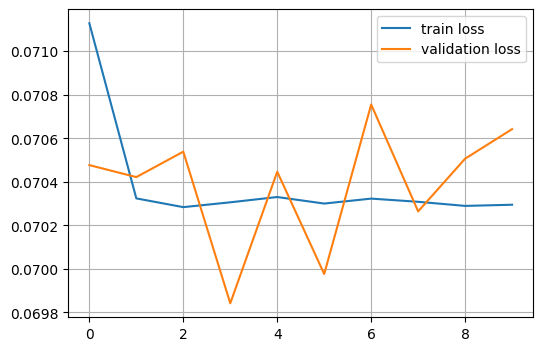

In [12]:
AutoUtils.PlotKKFoldLoss(results)

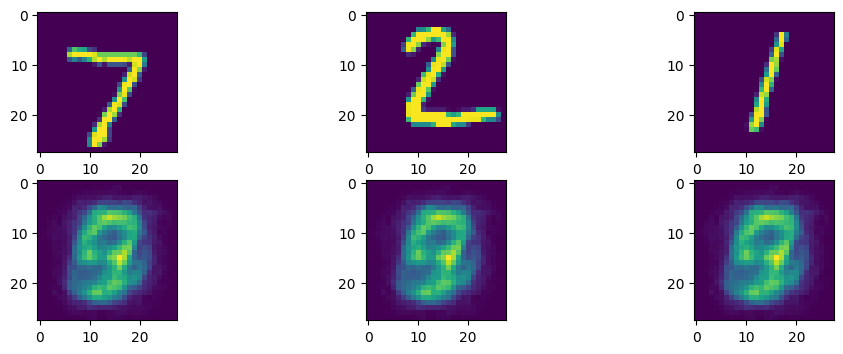

In [14]:
numbers_to_plot = 3
fig, ax = plt.subplots(2,3, figsize=(12,4))

for index, (image, _) in enumerate(test_dataset): 
    if (index >= numbers_to_plot):
        break
    item = image.reshape(-1, 28, 28)
    ax[0,index].imshow(item[0].detach().numpy())
    best_model.eval()
    item = best_model(image.reshape(-1, input_shape).to(DEVICE))
    item = item.reshape(-1, 28, 28).cpu()
    ax[1,index].imshow(item[0].detach().numpy())

plt.show()

## Denoising 

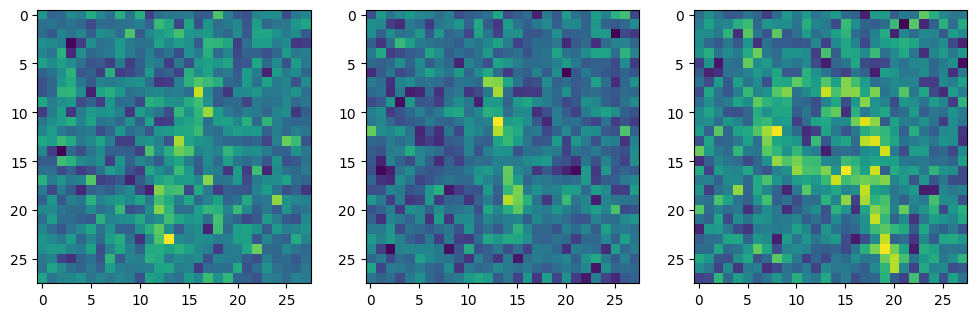

In [18]:
input_shape = 28 * 28
numbers_to_plot = 3
fig, ax = plt.subplots(1,3, figsize=(12,4))

for index, (image, _) in enumerate(train_loader): 
    if (index >= numbers_to_plot):
        break
    item = image.reshape(-1, 28, 28)
    noise = torch.normal(0, 0.5, size=item.shape)
    item += noise
    ax[index].imshow(item[0])
plt.show()

In [4]:
def NoiseTrain(model, 
        optimizer,
        loss_function,
        train_loader,
        input_shape):
        acumulated_loss = 0
        model.train()
        num_batches = len(train_loader) 
        for (image, _) in train_loader:
                optimizer.zero_grad()
                input_data = torch.flatten(image, start_dim=1).to(DEVICE) 
                noise_data = input_data + torch.normal(0, 0.5, size=input_data.shape).to(DEVICE)
                model_output = model(noise_data)
                loss = loss_function(model_output, input_data)
                # Update weights
                loss.backward()
                optimizer.step()
                acumulated_loss += loss.item()
        avg_loss = acumulated_loss / num_batches
        return avg_loss, model

In [5]:
def NoiseValidation(model, 
        optimizer,
        loss_function,
        validation_loader,
        input_shape):
        model.eval()
        valid_loss = 0
        num_batches = len(validation_loader)
        with torch.no_grad():  # Disable gradient computation
                for (image, _)  in validation_loader:
                        input_data = torch.flatten(image, start_dim=1).to(DEVICE) 
                        noise_data = input_data + torch.normal(0, 0.5, size=input_data.shape).to(DEVICE)
                        model_output = model(noise_data)
                        loss = loss_function(model_output, input_data)
                        valid_loss += loss.item()
                avg_valid_loss = valid_loss / num_batches 
        return avg_valid_loss

In [6]:
import SimpleAutoencoder as sae

if (inputData == "MNIST"):
    input_shape = 28 * 28
else:
    input_shape = 4

param_grid = ParameterGrid(
    {
        'epoch': [10],
        'lr': [1e-3],
        "hyper_parameter": [1]
    })

results = {
    "train_loss": list(),
    "validation_loss": list(),
    "epoch": list(),
    "fold": list()}
best_model_flag = 9e99
best_model = None

for model_configuration in param_grid:
    epoch = model_configuration["epoch"]
    lr = model_configuration["lr"]
    hyper_parameter = model_configuration["hyper_parameter"]

    print(f"{epoch = }\t{lr = }")
    cv = CrossValidation(5)
    for fold_index, dataloaders in enumerate(cv.GetSplitDataloader(dataset)):
        train_loader, validation_loader = dataloaders
        # Model
        model = sae.SimpleAutoencoder(input_shape).to(DEVICE)
        loss_function = nn.MSELoss()
        optimizer = optim.Adam(model.parameters(),
                                lr = lr)
        print(f"{fold_index = }")
        for n_epoch in tqdm(range(epoch)):
            total_train_loss, model = NoiseTrain(model, optimizer, loss_function, train_loader,
                            input_shape)
            total_validation_loss = NoiseValidation(model, optimizer, loss_function, validation_loader,
                            input_shape)
            results["train_loss"].append(total_train_loss)
            results["validation_loss"].append(total_validation_loss)
            results["fold"].append(fold_index)
            if total_train_loss <= best_model_flag:
                best_model = model
                best_model_flag = total_train_loss

print(best_model)

epoch = 10	lr = 0.001
fold_index = 0


  0%|          | 0/10 [00:00<?, ?it/s]

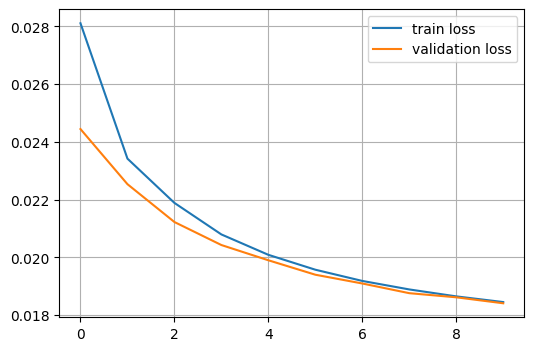

In [ ]:
AutoUtils.PlotKKFoldLoss(results)

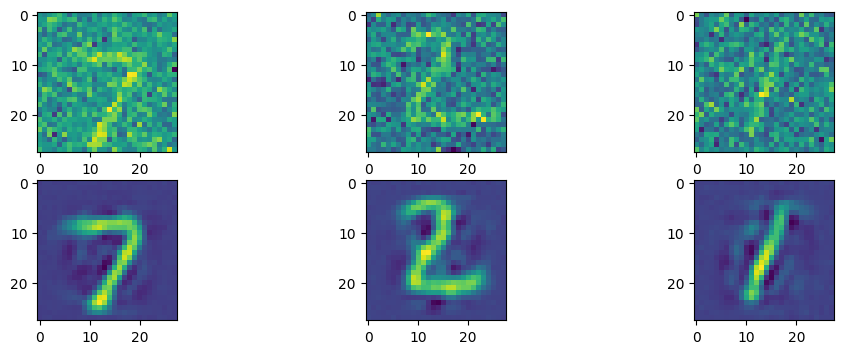

In [ ]:
numbers_to_plot = 3
fig, ax = plt.subplots(2,3, figsize=(12,4))

for index, (image, _) in enumerate(test_dataset): 
    if (index >= numbers_to_plot):
        break
    input_data = image.reshape(-1, input_shape).to(DEVICE)
    noise_data = input_data + torch.normal(0, 0.5, size=input_data.shape).to(DEVICE)
    item = noise_data.reshape(-1, 28, 28)
    ax[0,index].imshow(item[0].cpu())
    model.eval()
    item = model(noise_data)
    item = item.reshape(-1, 28, 28).cpu()
    ax[1,index].imshow(item[0].detach().numpy())

plt.show()

## Contractive

In [29]:
def contractive_loss(model, model_output, input_data, hyper_parameter):
    """
    Source: https://github.com/AlexPasqua/Autoencoders/blob/main/src/custom_losses.py
    Actual function computing the loss of a contractive autoencoder
    :param input: (Tensor)
    :param target: (Tensor)
    :param lambd: (float) regularization parameter
    :param ae: (DeepAutoencoder) the model itself, used to get it's weights
    :param reduction: (str) type of reduction {'mean' | 'sum'}
    :raises: ValueError
    :return: the loss
    """
    enc_weights = [model.encoder[i].weight for i in reversed(range(0, len(model.encoder), 2))]
    return hyper_parameter * torch.norm(torch.chain_matmul(*enc_weights))

In [40]:
def ContractiveTrain(model, 
        optimizer,
        loss_function,
        train_loader,
        input_shape,
        regularizer,
        hyper_parameter):
        acumulated_loss = 0
        model.train()
        num_batches = len(train_loader) 
        for (image, _) in train_loader:
                optimizer.zero_grad()
                input_data = torch.flatten(image, start_dim=1).to(DEVICE) 
                # Consume input
                model_output = model(input_data)
                mre_loss = loss_function(model_output, input_data)
                # Addin regularization
                regularizer_value =  regularizer(model, model_output,
                                        input_data, hyper_parameter)
                loss = torch.sum(torch.mean(mre_loss + regularizer_value, 0))
                # Update weights
                loss.backward()
                optimizer.step()
                acumulated_loss += loss.item()
        avg_loss = acumulated_loss / num_batches
        return avg_loss, model

In [41]:
def ContractiveValidation(model, 
        optimizer,
        loss_function,
        validation_loader,
        input_shape,
        regularizer,
        hyper_parameter):
        model.eval()
        valid_loss = 0
        num_batches = len(validation_loader)
        with torch.no_grad():  # Disable gradient computation
                for (image, _)  in validation_loader:
                        input_data = torch.flatten(image, start_dim=1).to(DEVICE) 
                        model_output = model(input_data)
                        mre_loss = loss_function(model_output, input_data)
                        # Addin regularization
                        regularizer_value =  regularizer(model, model_output,
                                                        input_data, hyper_parameter)
                        loss = torch.sum(torch.mean(mre_loss + regularizer_value, 0))
                        valid_loss += loss.item()
                avg_valid_loss = valid_loss / num_batches 
        return avg_valid_loss

In [42]:
import SimpleAutoencoder as sae

if (inputData == "MNIST"):
    input_shape = 28 * 28
else:
    input_shape = 4

param_grid = ParameterGrid(
    {
        'epoch': [10],
        'lr': [1e-3],
        "hyper_parameter": [0.000001]
    })

results = {
    "train_loss": list(),
    "validation_loss": list(),
    "epoch": list(),
    "fold": list()}
best_model_flag = 9e99
best_model = None

for model_configuration in param_grid:
    epoch = model_configuration["epoch"]
    lr = model_configuration["lr"]
    hyper_parameter = model_configuration["hyper_parameter"]

    print(f"{epoch = }\t{lr = }")
    cv = CrossValidation(5)
    for fold_index, dataloaders in enumerate(cv.GetSplitDataloader(dataset)):
        train_loader, validation_loader = dataloaders
        # Model
        model = sae.SimpleAutoencoder(input_shape).to(DEVICE)
        loss_function = nn.MSELoss()
        optimizer = optim.Adam(model.parameters(),
                                lr = lr)
        print(f"{fold_index = }")
        for n_epoch in tqdm(range(epoch)):
            total_train_loss, model = ContractiveTrain(model, optimizer, loss_function, train_loader,
                            input_shape, contractive_loss, hyper_parameter)
            total_validation_loss = ContractiveValidation(model, optimizer, loss_function, validation_loader,
                            input_shape, contractive_loss, hyper_parameter)
            results["train_loss"].append(total_train_loss)
            results["validation_loss"].append(total_validation_loss)
            results["fold"].append(fold_index)
            if total_train_loss <= best_model_flag:
                best_model = model
                best_model_flag = total_train_loss

print(best_model)

epoch = 10	lr = 0.001
fold_index = 0


  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [01:11<00:00,  7.13s/it]


fold_index = 1


100%|██████████| 10/10 [01:11<00:00,  7.14s/it]


...

fold_index = 3


100%|██████████| 10/10 [01:11<00:00,  7.14s/it]


fold_index = 4


100%|██████████| 10/10 [01:12<00:00,  7.22s/it]

SimpleAutoencoder(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): Tanh()
    (2): Linear(in_features=256, out_features=64, bias=True)
    (3): Tanh()
  )
  (decoder): Sequential(
    (0): Linear(in_features=64, out_features=256, bias=True)
    (1): Tanh()
    (2): Linear(in_features=256, out_features=784, bias=True)
    (3): Tanh()
    (4): Linear(in_features=784, out_features=784, bias=True)
  )
)


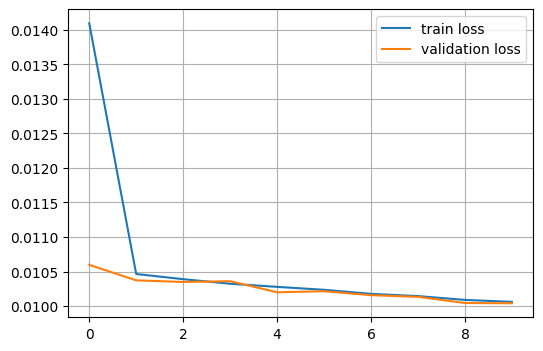

In [43]:
AutoUtils.PlotKKFoldLoss(results)

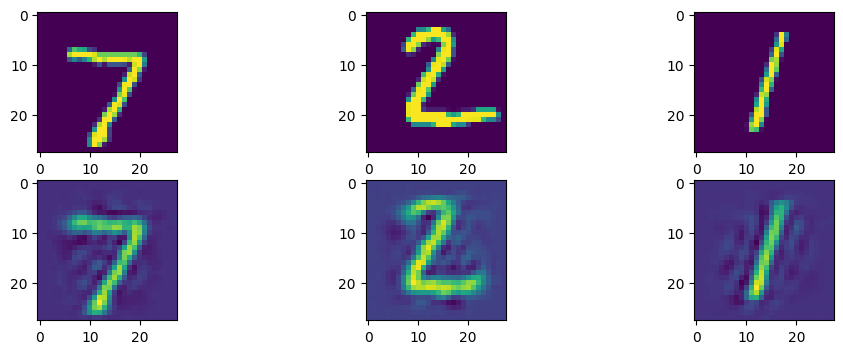

In [44]:
numbers_to_plot = 3
fig, ax = plt.subplots(2,3, figsize=(12,4))

for index, (image, _) in enumerate(test_dataset): 
    if (index >= numbers_to_plot):
        break
    item = image.reshape(-1, 28, 28)
    ax[0,index].imshow(item[0].detach().numpy())
    best_model.eval()
    item = best_model(image.reshape(-1, input_shape).to(DEVICE))
    item = item.reshape(-1, 28, 28).cpu()
    ax[1,index].imshow(item[0].detach().numpy())

plt.show()